# The "step out of stocks" oracle — does a financial-conditions index time the market? 🌡️
### Why a gauge that screams "tighten up!" right as stocks fall is a thermometer, not a crystal ball

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Step_out_of_stocks%3F: Misattributed](https://img.shields.io/badge/Step_out_of_stocks%3F-Misattributed-8b949e?style=flat-square)

There's a piece of macro folklore that sounds airtight: the Chicago Fed's **National Financial Conditions Index (NFCI)** — a weekly number where **positive means tighter-than-average conditions** — is sold as an equity regime switch. *When conditions turn tight, step out of stocks; when they loosen, get back in.* And the headline correlation is jaw-dropping: tight weeks and down weeks move together almost lock-step.

That correlation is real. It's also a **trap**. A conditions index like the NFCI is built *partly out of equity volatility* — so "conditions tightened this week" and "stocks fell this week" are two names for the *same event*. The number that looks like a market-timing oracle is really a **thermometer**: it tells you it's raining **now**, not that it'll rain next week. This notebook pulls the two apart in plain English.

> 📓 **Plain-language layer.** Want the Welch *t*, the placebo test and the contemporaneous-vs-forward decomposition? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** The true NFCI lives only on FRED, which isn't reachable here, so we **build a transparent proxy** from four tradable risk gauges (equity vol, rates vol, a credit spread, broad-dollar momentum), z-scored to NFCI's sign (**high = tight**). It's narrower and noisier — we call it a proxy throughout — and it's *also* made partly of equity vol, exactly like the real thing, so the lesson carries straight over. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from nfci_conditions import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("real conditions-proxy cache present:", HAVE_REAL,
      "| weeks:", (0 if F is None else len(F)),
      "| tight weeks:", (0 if F is None else int(st.tight_mask(F['fci']).sum())))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2002-01-04', 'end': '2026-06-19', 'weeks': 1277, 'years': 24.5, 'n_tight': 271, 'pct_tight': 21, 'thresh': 0.5, 'contemp': -0.728, 'h1': (1, 271, 0.08, 53, 0.18, 57, -0.38, 0.264), 'h4': (4, 271, 0.66, 58, 0.7, 64, -0.09, 0.443), 'h13': (13, 269, 1.72, 62, 2.22, 70, -0.7, 0.134), 'timing': [(0, 90, 21, 0.71, 11.7, 0.53, 17.2, 0.18, 7.8, 7.8), (5, 90, 21, 0.69, 11.7, 0.53, 17.2, 0.16, 7.6, 7.8), (10, 90, 21, 0.67, 11.7, 0.53, 17.2, 0.15, 7.4, 7.8)], 'gap_full': 0.164, 'gap_ex2008': 0.091, 'robust': [(0.0, 483, 1.64, -1.17, 0.049), (0.5, 269, 1.72, -0.7, 0.134), (1.0, 136, 2.3, 0.08, 0.544)], 'syn': [(0.0, -0.27, 2.15, 2.06, 0.19, 0.592, -0.24), (0.006, -0.23, -0.47, 1.67, -3.94, 0.0, 0.46), (0.012, -0.17, -2.78, 1.62, -5.89, 0.0, 1.06)]}


real conditions-proxy cache present: True | weeks: 1277 | tight weeks: 271


## The answer first

| Question | Answer |
|---|---|
| Do tight weeks coincide with falling stocks? | **Yes — almost perfectly** (correlation **-0.73**). That's the scary-looking headline. |
| So can you trade it? | **No — that's a coincidence, not a forecast.** The index is *made of* equity volatility, so "conditions tightened" and "stocks fell" are the same event told twice. You can't trade something that happens *at the same time*. |
| Does tightness predict *next* week/month? | **Barely, and the wrong way for a strategy.** After a tight week the market does run a touch *weaker* than usual — the folklore's direction — but the gap is tiny and the strongest test is only **t = -0.70** (p = 0.13). Nowhere near significant. |
| But the "step out when tight" rule has a higher Sharpe! | **True — and it's volatility, not money.** The rule's Sharpe (**0.69** vs **0.53**) comes entirely from **cutting vol (17% → 12%**) at the **same CAGR**. It's a risk overlay, not an edge. |

> The conditions index is a great *thermometer* for the weather you're already in. It is not a *forecast*. The famous timing power is a contemporaneous coincidence wearing a forecaster's coat.

## 1 · The claim

> *"Watch the financial-conditions index. When it rises through zero into positive territory — conditions are tightening, credit is getting scarce, risk premia are blowing out — get out of stocks. When it falls back negative, conditions are easy again: get back in."*

The story is intuitive: tightening credit and rising risk premia choke off the liquidity that fuels equities, so a rising conditions index should *precede* equity weakness. The seduction is the chart — overlay the index on the S&P and they look like mirror images. We'll rebuild the index from tradable parts and ask the only question that matters for a trader: does tightness **today** tell you anything about **tomorrow**?

## 2 · So what?

Two very different links hide inside that scary correlation, and only one of them could ever make money. (1) The **contemporaneous** link — do tight *weeks* line up with down *weeks*? Of course they do: the index is partly built from equity vol, so this is near-tautological and **predicts nothing** (by the time you see it, the move already happened). (2) The **forward** link — does tightness measured *this* week beat the base rate for *next* week's return? That's the only thing you can act on. The folklore quietly sells you the first and lets you believe it's the second. And separately: even a rule that *lowers volatility* isn't necessarily giving you *more money* — those are different things, and Sharpe alone can't tell them apart.

## 3 · How would we even know?

We rebuild the conditions index as a **transparent four-leg proxy** — equity vol (`^VIX`), rates vol (`^MOVE`), an IG-vs-Treasury credit spread (`LQD`/`IEF`) and broad-dollar momentum (`UUP`) — z-scored so **high = tight**, just like the NFCI. Over **24 years** (2002-01-04 → 2026-06-19, 1,277 weeks) we call a week **tight** when the index is at/above **+0.5 z** (~the top fifth; **271** weeks).

1. **Show the coincidence.** Confirm the eye-catching same-week link — and label it for what it is.
2. **Isolate the forecast.** For each tight week, measure what the market did over the **next** 1 / 4 / 13 weeks (entered a week *later*, no peeking), vs a *random* week (the base rate).
3. **Stress the luck.** Draw the same number of *random* weeks thousands of times and ask how often pure chance looks as bearish as the tight set. And run the actual "step out when tight" rule to see where its Sharpe really comes from.

## 4 · The teardown — let's actually look

**First, the coincidence.** Here's the *same-week* relationship: how the conditions index *changed* this week vs what the S&P *did* this week. This is the number the folklore waves around — and it's a coincidence, not a forecast.

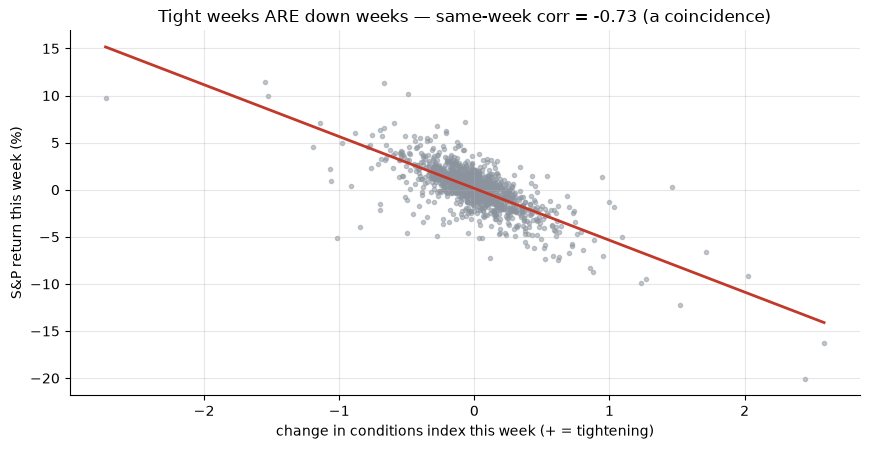

contemporaneous correlation (dFCI vs SPY return): -0.728


In [2]:
if HAVE_REAL:
    r = np.log(F['spy']).diff()
    dfci = F['fci'].diff()
    both = np.c_[r.values, dfci.values]
    both = both[~np.isnan(both).any(axis=1)]
    cc = st.contemporaneous_corr(F)
    fig, ax = plt.subplots(figsize=(8.8, 4.6))
    ax.scatter(both[:,1], both[:,0]*100, s=9, c=GREY, alpha=.5)
    a, b = np.polyfit(both[:,1], both[:,0]*100, 1)
    xs = np.linspace(both[:,1].min(), both[:,1].max(), 50)
    ax.plot(xs, a*xs+b, c=RED, lw=2)
    ax.set_xlabel('change in conditions index this week (+ = tightening)')
    ax.set_ylabel('S&P return this week (%)')
    ax.set_title(f'Tight weeks ARE down weeks — same-week corr = {cc:.2f} (a coincidence)')
    plt.tight_layout(); plt.show()
    print('contemporaneous correlation (dFCI vs SPY return):', round(cc, 3))
else:
    cc = R['contemp']
    print('no cache — frozen contemporaneous correlation:', cc)

That **-0.73** is the whole magic trick. It looks like a market-timing superpower, but it's *mechanical*: the index embeds equity vol, so a week where stocks tanked is *by construction* a week where the index spiked. It happened **at the same time** — there's no foresight in it. Now the real test.

**The forecast vs a normal week.** For each horizon, what did the S&P actually do *after* a tight week (entered a week later, no peeking), next to the base rate — what a random week gives you anyway?

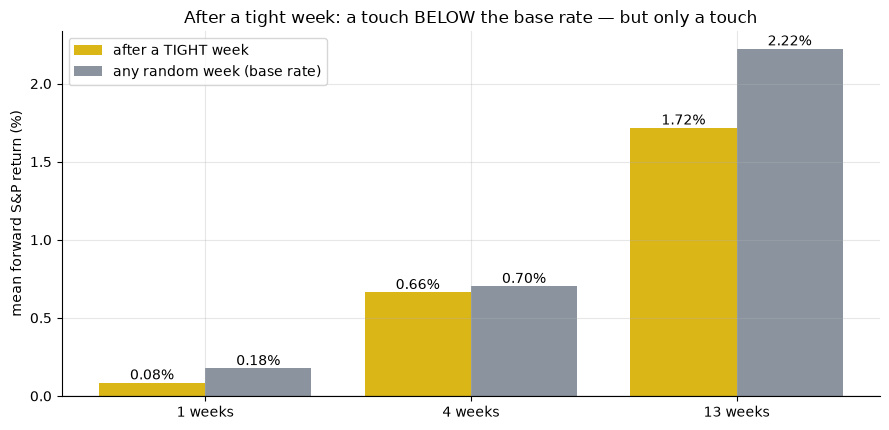

13-week: tight 1.72% vs base 2.22%


In [3]:
hs = [1, 4, 13]
if HAVE_REAL:
    rows = [st.summarize(F, h) for h in hs]
    cmean = [r['cond_mean']*100 for r in rows]; bmean = [r['base_mean']*100 for r in rows]
else:
    cmean = [R['h1'][2], R['h4'][2], R['h13'][2]]
    bmean = [R['h1'][4], R['h4'][4], R['h13'][4]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x-.2, cmean, .4, color=AMBER, label='after a TIGHT week')
ax.bar(x+.2, bmean, .4, color=GREY, label='any random week (base rate)')
ax.set_xticks(x); ax.set_xticklabels([f'{m} weeks' for m in hs])
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('mean forward S&P return (%)')
ax.set_title('After a tight week: a touch BELOW the base rate — but only a touch')
for i,(c,b) in enumerate(zip(cmean,bmean)):
    ax.annotate(f'{c:.2f}%',(i-.2,c),ha='center',va='bottom')
    ax.annotate(f'{b:.2f}%',(i+.2,b),ha='center',va='bottom')
ax.legend(); plt.tight_layout(); plt.show()
print('13-week: tight', f'{cmean[-1]:.2f}%', 'vs base', f'{bmean[-1]:.2f}%')

Here's the anticlimax. After a tight week the market *is* a touch weaker than usual — at 13 weeks **+1.72%** vs a base **+2.22%** — which is the *direction* the folklore promises. But the gap is **small**: a few tenths of a percent. The terrifying −0.73 evaporates the moment you wait one week. The thermometer told you it was raining; it didn't tell you tomorrow's weather.

**Could random weeks look this bearish?** The honest small-sample test: draw **271** *random* weeks over and over, and see how often pure luck produces a 13-week forward return at least as weak as the tight set's.

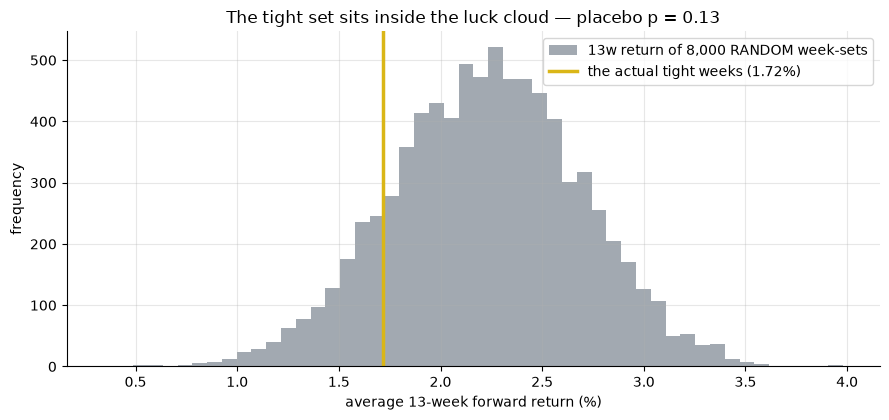

a random week-set is at least as bearish 13% of the time — far from rare


In [4]:
if HAVE_REAL:
    s13 = st.summarize(F, 13); obs = s13['cond_mean']; pval = s13['p_placebo']
    fwd = st.forward_returns(F['spy'], 13).dropna().values
    k = s13['n']
    rng = np.random.default_rng(386)
    draws = np.array([fwd[rng.integers(0, len(fwd), size=k)].mean() for _ in range(8000)])
else:
    obs = R['h13'][2]/100; pval = R['h13'][7]
    rng = np.random.default_rng(386); draws = rng.normal(R['h13'][4]/100, 0.012, 8000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=50, color=GREY, alpha=.8, label=f'13w return of {len(draws):,} RANDOM week-sets')
ax.axvline(obs*100, c=AMBER, lw=2.5, label=f'the actual tight weeks ({obs*100:.2f}%)')
ax.set_xlabel('average 13-week forward return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The tight set sits inside the luck cloud — placebo p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'a random week-set is at least as bearish {pval*100:.0f}% of the time — far from rare')

The amber line — the actual tight weeks — falls **inside** the grey cloud of random draws. About **13%** of random week-sets are at least as bearish. In plain terms: **the tight set's slightly-below-average forward return is exactly what chance produces all the time.** No foresight, just noise around a small, correctly-signed tilt.

## 5 · The verdict

- **Signal — Weak.** Tightness is correctly *signed* against forward returns (the lore's direction) — but the effect is tiny, **fails the t ≥ 2 bar** at every horizon (13-week **t = -0.70**, p = 0.13), and even **flips sign** at the tightest cut. The jaw-dropping **−0.73** is *contemporaneous* and carries no foresight. Direction-right, significance-absent.
- **Tradability — Fragile.** "Step out when tight" *does* lift Sharpe (**0.69** vs **0.53**) — but purely by cutting vol (**17% → 12%**) at the **same CAGR (~7.7%)**. The bump *halves* without the 2008 crisis and its confidence interval straddles zero. A vol overlay a leverage-matched benchmark erases — not an edge.
- **"Step out of stocks?" — Misattributed.** The signal's apparent power is the index *being built from the very thing it claims to predict*. It's a thermometer dressed as a forecast — the same nowcaster-as-timer error as the [Sahm Rule](../../268-sahm-rule/) and the [Fed Model](../../118-fed-model/).

## 6 · Could you actually trade it? — where the Sharpe really comes from

Forget significance for a second and run the actual rule: hold cash the week after the index is tight, otherwise hold the S&P. Yes, the Sharpe goes up. But look at *why* — split the result into **return** and **volatility**.

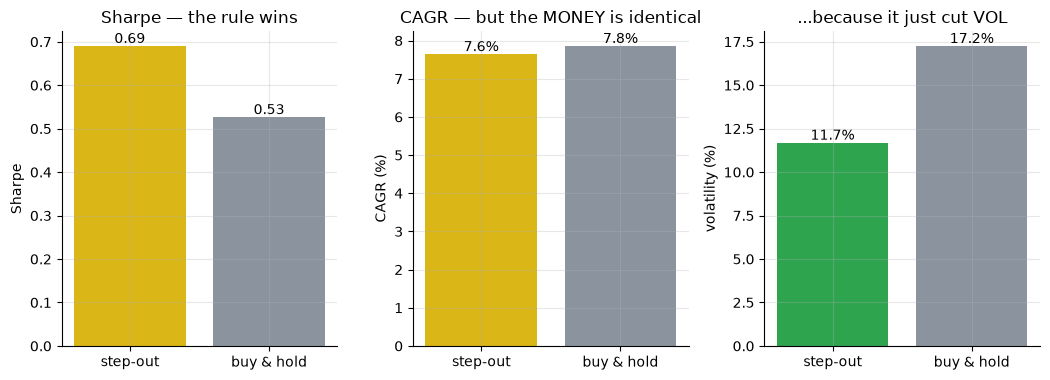

Sharpe 0.69 vs 0.53; CAGR 7.6% vs 7.8%; vol 11.7% vs 17.2%


In [5]:
if HAVE_REAL:
    b = st.backtest_timing(F, cost_bps=5.0)
    s_sh, b_sh = b['strat_sharpe'], b['bh_sharpe']
    s_vol, bh_vol = b['strat_ann_vol']*100, b['bh_ann_vol']*100
    s_cagr, bh_cagr = b['strat_cagr']*100, b['bh_cagr']*100
else:
    _, _, _, s_sh, s_vol, b_sh, bh_vol, _, s_cagr, bh_cagr = R['timing'][1]
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(10.6, 3.9))
a1.bar(['step-out', 'buy & hold'], [s_sh, b_sh], color=[AMBER, GREY])
a1.set_title('Sharpe — the rule wins'); a1.set_ylabel('Sharpe')
for i,v in enumerate([s_sh,b_sh]): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
a2.bar(['step-out', 'buy & hold'], [s_cagr, bh_cagr], color=[AMBER, GREY])
a2.set_title('CAGR — but the MONEY is identical'); a2.set_ylabel('CAGR (%)')
for i,v in enumerate([s_cagr,bh_cagr]): a2.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
a3.bar(['step-out', 'buy & hold'], [s_vol, bh_vol], color=[GREEN, GREY])
a3.set_title('...because it just cut VOL'); a3.set_ylabel('volatility (%)')
for i,v in enumerate([s_vol,bh_vol]): a3.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f'Sharpe {s_sh:.2f} vs {b_sh:.2f}; CAGR {s_cagr:.1f}% vs {bh_cagr:.1f}%; vol {s_vol:.1f}% vs {bh_vol:.1f}%')

There's the whole story in three bars. The **Sharpe** rises, but the **CAGR is identical** — the rule earns you *no extra money*. All it does is **cut volatility** by sitting out the highest-vol weeks (which cluster, so last week's tight reading predicts *this* week's vol — but not its *direction*). That's a **risk-reduction overlay**, not alpha. A leverage-matched buy-and-hold at the same vol would erase the entire Sharpe gap. Costs, by the way, barely matter — frequency and *kind* of edge do.

## 7 · Going further 🚪

- **The same mistake, other gauges.** [Study 268 — Sahm Rule](../../268-sahm-rule/) and [Study 118 — Fed Model](../../118-fed-model/) are the same genre: a macro nowcaster that *describes the present* sold as a tool that *forecasts the future*.
- **The liquidity cousin.** [Study 317 — Fed Balance Sheet](../../317-fed-balance-sheet/) asks whether central-bank liquidity (QE/QT) times equities — the same conditions-drive-stocks thesis from the supply side.
- **Build your own conditions index.** Swap our four legs for the real NFCI (if you can reach FRED), or add more credit/term-spread legs — the contemporaneous −0.7 will survive and the forward edge still won't clear the bar. The lesson is the *kind* of link, not the exact recipe.

*Think tightness forecasts more than the base rate? Isolate the **forward** link with a one-week lag, draw the same number of random weeks, and show the tight set landing **outside** the cloud — then we'll talk.*